# Phrase Inference

Run a trained phrase-detection model on a new song and export an importable label JSON.

**Bundle-driven:** all feature extraction, per-track normalization, and Viterbi smoothing
are read from the model bundle itself (see `scripts/train_phrase_model.py`). To swap models,
just change `MODEL_PATH` — the right features + post-processing follow automatically.

Available bundles in `models/phrase_detection/`:
- `phrase_xgb_viterbi.joblib` — **recommended** (XGBoost + features + Viterbi, Macro F1 0.84)
- `phrase_rf_viterbi.joblib` — dependency-free alternative (RandomForest, Macro F1 0.82)
- `phrase_mlp_baseline.joblib` — old baseline (log-mel only MLP, Macro F1 0.69)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from phrase_inference import load_bundle, make_track, predict_track, to_label_json
import json

PHRASE_COLORS = {
    "quiet": "#6baed6", "verse": "#fdae6b", "lead": "#9e9ac8", "buildUp": "#fd8d3c",
    "preDropFill": "#d94801", "drop": "#e6550d", "bridge": "#74c476",
}

def plot_timeline(ax, pred_df, title):
    for _, r in pred_df.iterrows():
        ax.barh(0, r["end"] - r["start"], left=r["start"], height=1,
                color=PHRASE_COLORS.get(r["prediction"], "#ccc"), edgecolor="none")
    ax.set_xlim(pred_df["start"].iloc[0], pred_df["end"].iloc[-1])
    ax.set_yticks([]); ax.set_title(title)

In [18]:
# --- Knobs: edit per song ---
INFER_AUDIO_PATH = PROJECT_ROOT / "data" / "audio" / "Damaxy, Detailed & Revelation - Start Your Engine (Official Video).m4a"
INFER_BPM        = 160.0   # must be accurate
INFER_OFFSET     = 0.021   # downbeat offset in seconds
MODEL_PATH       = PROJECT_ROOT / "models" / "phrase_detection" / "phrase_xgb_viterbi.joblib"

/Users/eerr/Documents/Projects/Timecode/-meow/scripts/phrase_inference.py:29: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  dur = librosa.get_duration(path=str(audio_path))
/Users/eerr/Documents/Projects/Timecode/-meow/scripts/phrase_features.py:120: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path.as_posix(), sr=SR, mono=True)
/Users/eerr/Documents/Projects/Timecode/-meow/.venv/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Model: XGBClassifier | Viterbi: True
168 bars predicted


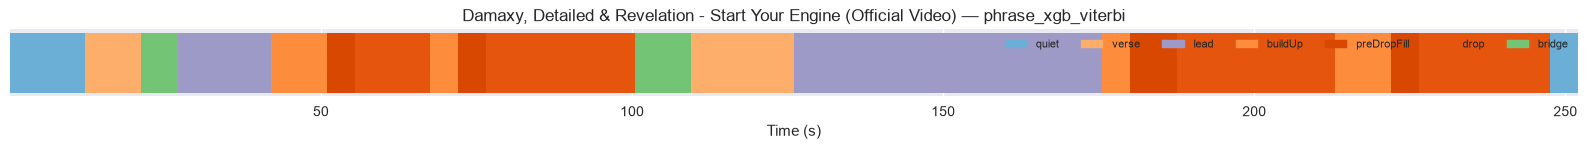

,bar,start,end,prediction,confidence
0,0,0.021,1.521,quiet,0.642782
1,1,1.521,3.021,quiet,0.833340
2,2,3.021,4.521,quiet,0.966990
3,3,4.521,6.021,quiet,0.944646
4,4,6.021,7.521,quiet,0.990262
...,...,...,...,...,...
163,163,244.521,246.021,drop,0.999453
164,164,246.021,247.521,drop,0.969137
165,165,247.521,249.021,quiet,0.993422
166,166,249.021,250.521,quiet,0.999570


In [19]:
# --- Run inference ---
bundle = load_bundle(MODEL_PATH)
track = make_track(INFER_AUDIO_PATH, INFER_BPM, INFER_OFFSET)
pred = predict_track(bundle, track, audio_dir=INFER_AUDIO_PATH.parent)

print(f"Model: {bundle['meta'].get('model')} | Viterbi: {bundle.get('apply_viterbi')}")
print(f"{len(pred)} bars predicted")

fig, ax = plt.subplots(figsize=(16, 1.6))
plot_timeline(ax, pred, f"{INFER_AUDIO_PATH.stem} — {Path(MODEL_PATH).stem}")
ax.legend(handles=[Patch(color=c, label=l) for l, c in PHRASE_COLORS.items()],
          loc="upper right", fontsize=8, ncol=len(PHRASE_COLORS))
ax.set_xlabel("Time (s)")
plt.tight_layout(); plt.show()
pred

In [20]:
# --- Export label JSON (importable into the website) ---
OUTPUT_PATH = INFER_AUDIO_PATH.with_suffix(".infer.json")
label_json = to_label_json(pred, track)
with open(OUTPUT_PATH, "w") as f:
    json.dump(label_json, f, indent=2)
print(f"Saved {len(label_json['phraseMarkers'])} markers -> {OUTPUT_PATH}")
pd.DataFrame(label_json["phraseMarkers"])

Saved 20 markers -> /Users/eerr/Documents/Projects/Timecode/-meow/data/audio/Damaxy, Detailed & Revelation - Start Your Engine (Official Video).infer.json


,phraseId,time,barCount,msSinceStart
0,quiet,10.521,7,10521
1,verse,19.521,13,19521
2,bridge,25.521,17,25521
3,lead,40.521,27,40521
4,buildUp,49.521,33,49521
5,preDropFill,54.021,36,54021
6,drop,66.021,44,66021
7,buildUp,70.521,47,70521
8,preDropFill,75.021,50,75021
9,drop,99.021,66,99021


## Compare models on the same song

Stack two or more models' predicted timelines to see how their predictions differ. Useful for
sanity-checking whether the smoothing / richer features actually help on a specific track.

In [ ]:
# --- Compare models ---
COMPARE = [
    "phrase_xgb_viterbi.joblib",
    "phrase_rf_viterbi.joblib",
    "phrase_mlp_baseline.joblib",
]

fig, axes = plt.subplots(len(COMPARE), 1, figsize=(16, 1.3 * len(COMPARE)))
if len(COMPARE) == 1:
    axes = [axes]
for ax, name in zip(axes, COMPARE):
    b = load_bundle(PROJECT_ROOT / "models" / "phrase_detection" / name)
    pdf = predict_track(b, track, audio_dir=INFER_AUDIO_PATH.parent)
    n_markers = len(to_label_json(pdf, track)["phraseMarkers"])
    plot_timeline(ax, pdf, f"{name}  ({n_markers} markers)")
axes[-1].legend(handles=[Patch(color=c, label=l) for l, c in PHRASE_COLORS.items()],
                loc="upper right", fontsize=7, ncol=len(PHRASE_COLORS))
axes[-1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()